In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

#### LOAD ROLES

In [2]:
roles = pd.read_csv("../data/rolle.tsv", sep="\t")
roles.loc[len(roles)] = [-1, 'UNKNOWN']
roles.loc[len(roles)] = [-0, 'REGIE']
roles = roles.rename(columns={'rolleID': 'speaker_id'})
roles = roles.set_index('speaker_id')
roles

,name
speaker_id,
1,"Hitchcock, Erzähler"
2,"Justus Jonas, Erster Detektiv"
3,"Peter Shaw, Zweiter Detektiv"
4,"Bob Andrews, Recherchen und Archiv"
5,"Mr. Fentriss, Schriftsteller"
...,...
2484,Alyssa
2485,Conrad Wilmington
2486,Haley Darlow


#### LOAD GENDER

In [3]:
# load gender
gender_df = pd.read_csv('../data/gender/gender.csv')
gender_df = gender_df.rename(columns={'rolleID': 'speaker_id'})
gender_df

,speaker_id,gender
0,1,m
1,2,m
2,3,m
3,4,m
4,5,m
...,...,...
1675,2483,m
1676,2484,f
1677,2485,m
1678,2486,f


#### LOAD COMBINED SCRIPTS

In [4]:
scripts = pd.read_csv('./combine.csv')
scripts = scripts.drop(columns=['Text','Page', 'Episode'])
scripts

,Speaker,speaker_id
0,REGIE,0
1,Justus,2
2,Peter,3
3,Justus,2
4,Peter,3
...,...,...
144388,Justus,2
144389,REGIE,0
144390,Peter,3
144391,Justus,2


#### GROUP SCRIPT LINES BY SPEAKER ID AND COUNT

In [5]:
speaker_counts = scripts.groupby(by='speaker_id').count()
speaker_counts = speaker_counts.rename(columns={'Speaker': 'count'})
speaker_counts

,count
speaker_id,
-1,9115
0,14998
1,92
2,35522
3,25184
...,...
2447,43
2469,2
2472,10


#### JOIN AND ADD REAL NAMES

In [6]:
speaker_counts = speaker_counts.join(roles, how='left', on='speaker_id')
speaker_counts = speaker_counts.sort_values(by='count', ascending=False)
speaker_counts = speaker_counts.reset_index()
speaker_counts

,speaker_id,count,name
0,2,35522,"Justus Jonas, Erster Detektiv"
1,4,25960,"Bob Andrews, Recherchen und Archiv"
2,3,25184,"Peter Shaw, Zweiter Detektiv"
3,0,14998,REGIE
4,-1,9115,UNKNOWN
...,...,...,...
1014,1806,1,Charles Stapleton
1015,1120,1,Menge
1016,1750,1,Helena
1017,1003,1,Sarah Livingston


#### ADD GENDER TO SPEAKER COUNTS

In [7]:
speaker_counts_gender = pd.merge(speaker_counts, gender_df, on='speaker_id', how='left')
speaker_counts_gender.head(15)

,speaker_id,count,name,gender
0,2,35522,"Justus Jonas, Erster Detektiv",m
1,4,25960,"Bob Andrews, Recherchen und Archiv",m
2,3,25184,"Peter Shaw, Zweiter Detektiv",m
3,0,14998,REGIE,NaN
4,-1,9115,UNKNOWN,NaN
5,574,3002,Erzähler,NaN
6,436,905,Inspektor Cotta,m
7,13,660,Tante Mathilda,f
8,39,388,Kommissar Reynolds,m
9,618,358,Jelena Charkova,f


#### VISUALISE TOP 15 SPEAKER

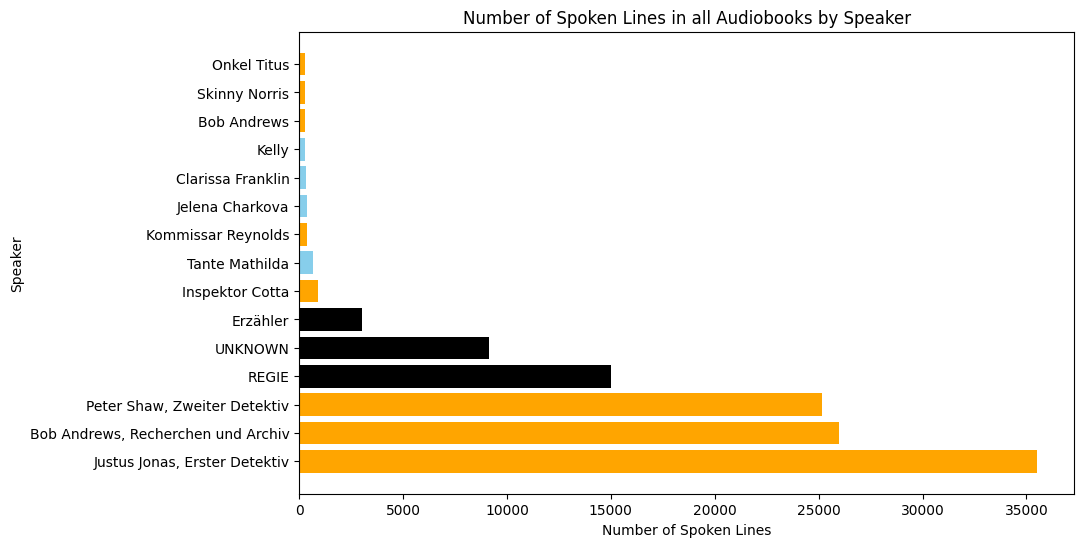

In [8]:
gender_colors = {'m': 'orange', 'f': 'skyblue', np.nan: 'black'}

fig, ax = plt.subplots(figsize=(10, 6))

for i, row in speaker_counts_gender.head(15).iterrows():
    ax.barh(row['name'], row['count'], color=gender_colors[row['gender']])

plt.title('Number of Spoken Lines in all Audiobooks by Speaker')
plt.xlabel('Number of Spoken Lines')
plt.ylabel('Speaker')
plt.show()

#### LIST NUMBER OF SPOKEN LINES PER GENDER

In [9]:
spoken_lines_by_gender = speaker_counts_gender.groupby(by='gender')['count'].sum()
spoken_lines_by_gender

gender
f      8893
m    100592
Name: count, dtype: int64

#### VISUALISE NUMBER OF SPOKEN LINES PER GENDER

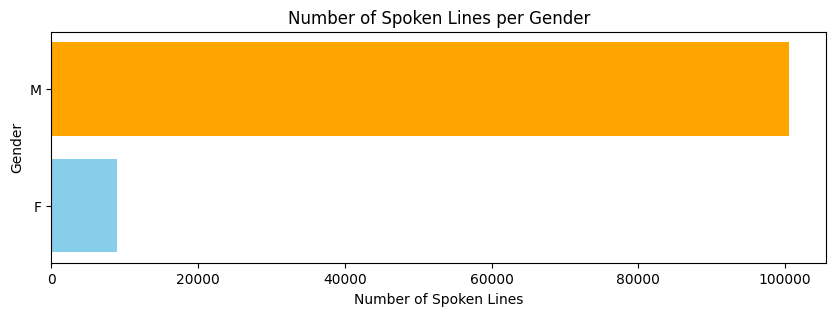

In [10]:
fig, ax = plt.subplots(figsize=(10, 3))

ax.barh('F', list(spoken_lines_by_gender)[0], color='skyblue')
ax.barh('M', list(spoken_lines_by_gender)[1], color='orange')

plt.title('Number of Spoken Lines per Gender')
plt.xlabel('Number of Spoken Lines')
plt.ylabel('Gender')
plt.show()

#### LIST GENDER UNKNOW, SORTED BY NUMBER OF LINES

In [11]:
unknown_gender = speaker_counts_gender[speaker_counts_gender['gender'].isna()].sort_values('count', ascending=False)
unknown_gender

,speaker_id,count,name,gender
3,0,14998,REGIE,NaN
4,-1,9115,UNKNOWN,NaN
5,574,3002,Erzähler,NaN
20,608,212,Blacky,NaN
27,629,167,Alpha,NaN
...,...,...,...,...
1008,910,1,Sam Reilly,NaN
1010,915,1,Devlin Reno,NaN
1014,1806,1,Charles Stapleton,NaN
1015,1120,1,Menge,NaN


#### List names UNKNOWN

In [12]:
unknowns = scripts.where(
    scripts['speaker_id']==-1
).groupby(
    by='Speaker'
).count().rename(
    columns={'speaker_id' : 'count'}
).sort_values(by='count', ascending=False)
unknowns

,count
Speaker,
Kenneth O'Ryan,172
Jeremy,118
Grace,117
Prof. Brewster,101
Chandler,97
...,...
Alle sagen,1
Alle vier,1
Alle zusammen,1
